In [1]:
# 1. Importación de librerías
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# 2. Cargar MNIST desde Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar y expandir dimensiones
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [ ]:
# 3. Definición de la arquitectura Siamesa


def build_base_model(input_shape=(28,28,1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(64)(x)  # embedding
    return Model(inputs, outputs)

# Modelo base
base_model = build_base_model()

# Entradas de la red siamesa
input_a = layers.Input(shape=(28,28,1))
input_b = layers.Input(shape=(28,28,1))

# Embeddings
emb_a = base_model(input_a)
emb_b = base_model(input_b)

# Distancia absoluta entre embeddings
distance = layers.Lambda(lambda tensors: tf.math.abs(tensors[0] - tensors[1]))([emb_a, emb_b])
outputs = layers.Dense(1, activation="sigmoid")(distance)

# Modelo siamesa final
siamese_model = Model([input_a, input_b], outputs)
siamese_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 64)        │    232,000 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 232,065 (906.50 KB)

 Trainable params: 232,065 (906.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. Generación de pares positivos y negativos


def make_pairs(images, labels):
    pairs, targets = [], []
    num_classes = len(np.unique(labels))
    idx = [np.where(labels == i)[0] for i in range(num_classes)]

    for idx_a in range(len(images)):
        current_image, label = images[idx_a], labels[idx_a]

        # Par positivo (misma clase)
        idx_b = np.random.choice(idx[label])
        pos_image = images[idx_b]
        pairs.append([current_image, pos_image])
        targets.append(1)

        # Par negativo (clase distinta)
        neg_label = np.random.choice([l for l in range(num_classes) if l != label])
        idx_c = np.random.choice(idx[neg_label])
        neg_image = images[idx_c]
        pairs.append([current_image, neg_image])
        targets.append(0)

    return np.array(pairs), np.array(targets)

# Generar pares con el dataset de entrenamiento y prueba
pairs_train, targets_train = make_pairs(x_train, y_train)
pairs_test, targets_test = make_pairs(x_test, y_test)

print("Total de pares de entrenamiento:", pairs_train.shape)
print("Total de pares de prueba:", pairs_test.shape)


Total de pares de entrenamiento: (120000, 2, 28, 28, 1)
Total de pares de prueba: (20000, 2, 28, 28, 1)


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 228s 61ms/step - accuracy: 0.9786 - loss: 0.0641 - val_accuracy: 0.9812 - val_loss: 0.0554
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 228s 61ms/step - accuracy: 0.9884 - loss: 0.0349 - val_accuracy: 0.9851 - val_loss: 0.0464
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 256s 59ms/step - accuracy: 0.9922 - loss: 0.0228 - val_accuracy: 0.9894 - val_loss: 0.0304
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 257s 58ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9894 - val_loss: 0.0374
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 265s 59ms/step - accuracy: 0.9956 - loss: 0.0123 - val_accuracy: 0.9884 - val_loss: 0.0414
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 233s 62ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9895 - val_loss: 0.0340
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 228s 61ms/step - accuracy: 0.9970 - loss: 0.0088 - val_accuracy: 0.9896 - val_loss: 0.0395
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 216s 58ms/step - accuracy: 

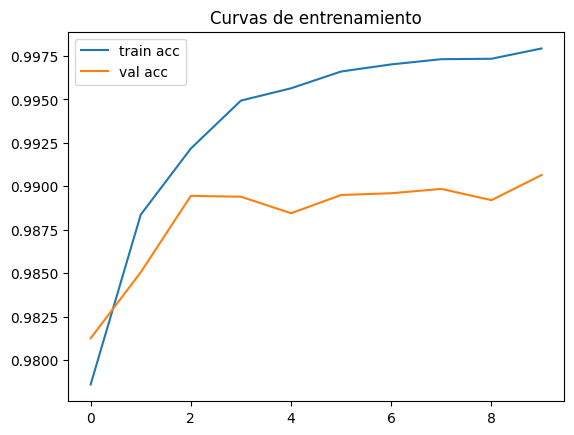

In [ ]:

# 5. Entrenamiento del modelo Siamesa


history = siamese_model.fit(
    [pairs_train[:,0], pairs_train[:,1]], targets_train,
    validation_data=([pairs_test[:,0], pairs_test[:,1]], targets_test),
    batch_size=32,
    epochs=10
)

# Graficar curvas de entrenamiento
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Curvas de entrenamiento")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


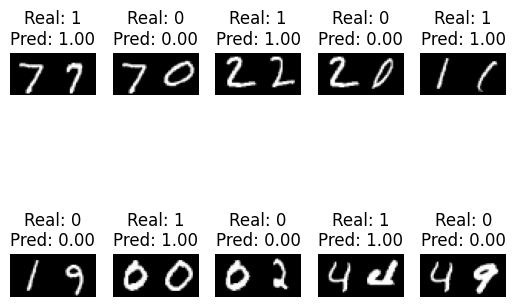

In [ ]:
# 6. Evaluación del modelo Siamesa


# Seleccionar algunos pares de prueba
sample_pairs = pairs_test[:10]
sample_targets = targets_test[:10]

# Hacer predicciones
preds = siamese_model.predict([sample_pairs[:,0], sample_pairs[:,1]])

# Mostrar resultados
for i in range(len(sample_pairs)):
    plt.subplot(2,5,i+1)
    plt.imshow(np.concatenate([sample_pairs[i,0], sample_pairs[i,1]], axis=1).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Real: {sample_targets[i]}\nPred: {preds[i][0]:.2f}")
plt.show()
